# Students Performance analysis using ML methods

## Importing & Getting dataframe

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('StudentsPerformance.csv')
df['sum score'] = df['math score'] + df['reading score'] + df['writing score']
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,sum score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282
996,male,group C,high school,free/reduced,none,62,55,55,172
997,female,group C,high school,free/reduced,completed,59,71,65,195
998,female,group D,some college,standard,completed,68,78,77,223


## Graphical Illustration & Analysis

(array([190.,   0., 319.,   0.,   0.,  89.,   0., 262.,   0., 140.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

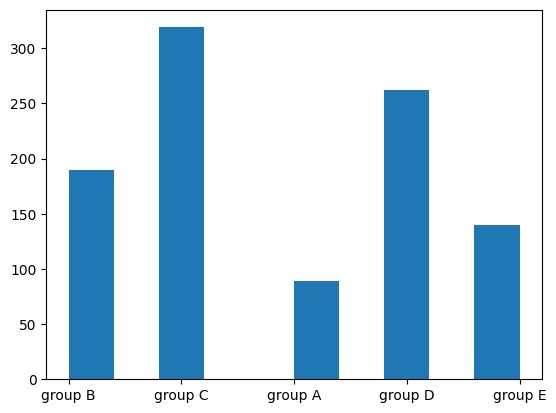

In [3]:
plt.hist(df['race/ethnicity'])

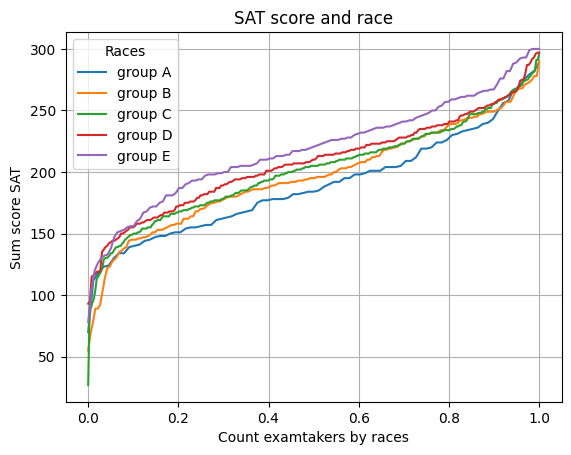

We can see that: group A is Blacks, group B is Hispanics, group C is Whites, group D is Asians, group E is Jews


In [4]:
df_plot = df.copy()
# df_plot = df_plot.groupby('race/ethnicity')['sum score'].apply(lambda x: x.sort_values().reset_index(drop=True)).reset_index()
for race_name, race in df_plot.groupby('race/ethnicity'):
    sorted_scores = race['sum score'].sort_values().values
    n = len(sorted_scores)
    normalized_index = np.linspace(0,1,n)
    plt.plot(normalized_index, sorted_scores, label=race_name)
plt.legend(title='Races')
plt.xlabel('Count examtakers by races')
plt.ylabel('Sum score SAT')
plt.title('SAT score and race')
plt.grid(True)
plt.show()
print('We can see that: group A is Blacks, group B is Hispanics, group C is Whites, group D is Asians, group E is Jews')

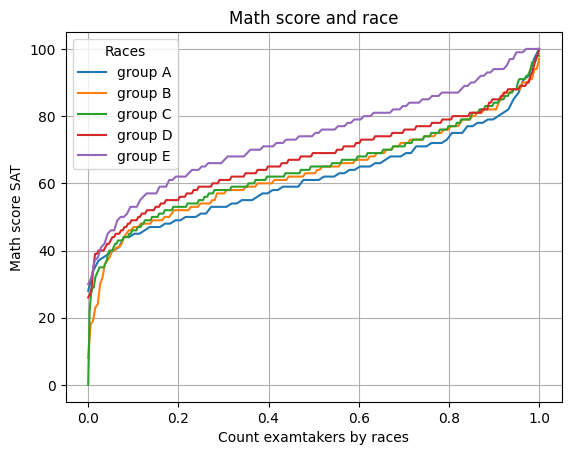

In [5]:
for race_name, race in df_plot.groupby('race/ethnicity'):
    sorted_scores = race['math score'].sort_values().values
    n = len(sorted_scores)
    normalized_index = np.linspace(0,1,n)
    plt.plot(normalized_index, sorted_scores, label=race_name)
plt.legend(title='Races')
plt.xlabel('Count examtakers by races')
plt.ylabel('Math score SAT')
plt.title('Math score and race')
plt.grid(True)
plt.show()

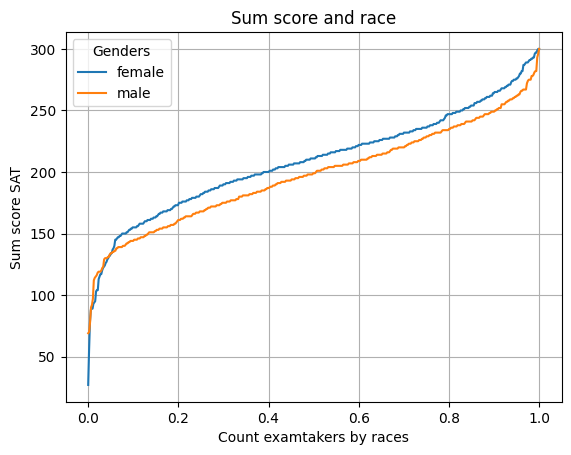

In [6]:
for race_name, race in df_plot.groupby('gender'):
    sorted_scores = race['sum score'].sort_values().values
    n = len(sorted_scores)
    normalized_index = np.linspace(0,1,n)
    plt.plot(normalized_index, sorted_scores, label=race_name)
plt.legend(title='Genders')
plt.xlabel('Count examtakers by races')
plt.ylabel('Sum score SAT')
plt.title('Sum score and race')
plt.grid(True)
plt.show()

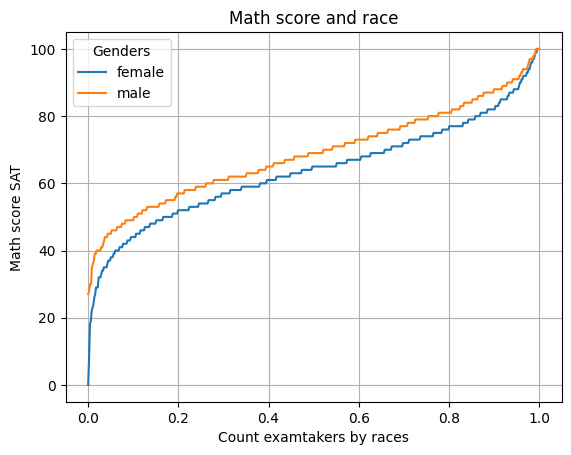

In [7]:
for race_name, race in df_plot.groupby('gender'):
    sorted_scores = race['math score'].sort_values().values
    n = len(sorted_scores)
    normalized_index = np.linspace(0,1,n)
    plt.plot(normalized_index, sorted_scores, label=race_name)
plt.legend(title='Genders')
plt.xlabel('Count examtakers by races')
plt.ylabel('Math score SAT')
plt.title('Math score and race')
plt.grid(True)
plt.show()

C:\Users\mythys\AppData\Local\Temp\ipykernel_24632\1590424611.py:5: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(normalized_index, sorted_scores, label=race_name)


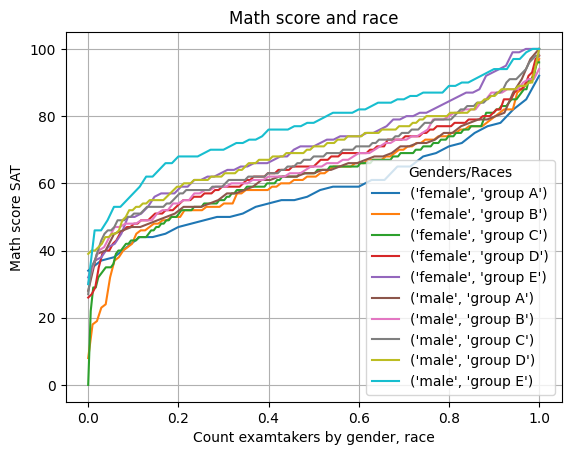

In [8]:
for race_name, race in df_plot.groupby(['gender', 'race/ethnicity']):
    sorted_scores = race['math score'].sort_values().values
    n = len(sorted_scores)
    normalized_index = np.linspace(0,1,n)
    plt.plot(normalized_index, sorted_scores, label=race_name)
plt.legend(title='Genders/Races')
plt.xlabel('Count examtakers by gender, race')
plt.ylabel('Math score SAT')
plt.title('Math score and race')
plt.grid(True)
plt.show()

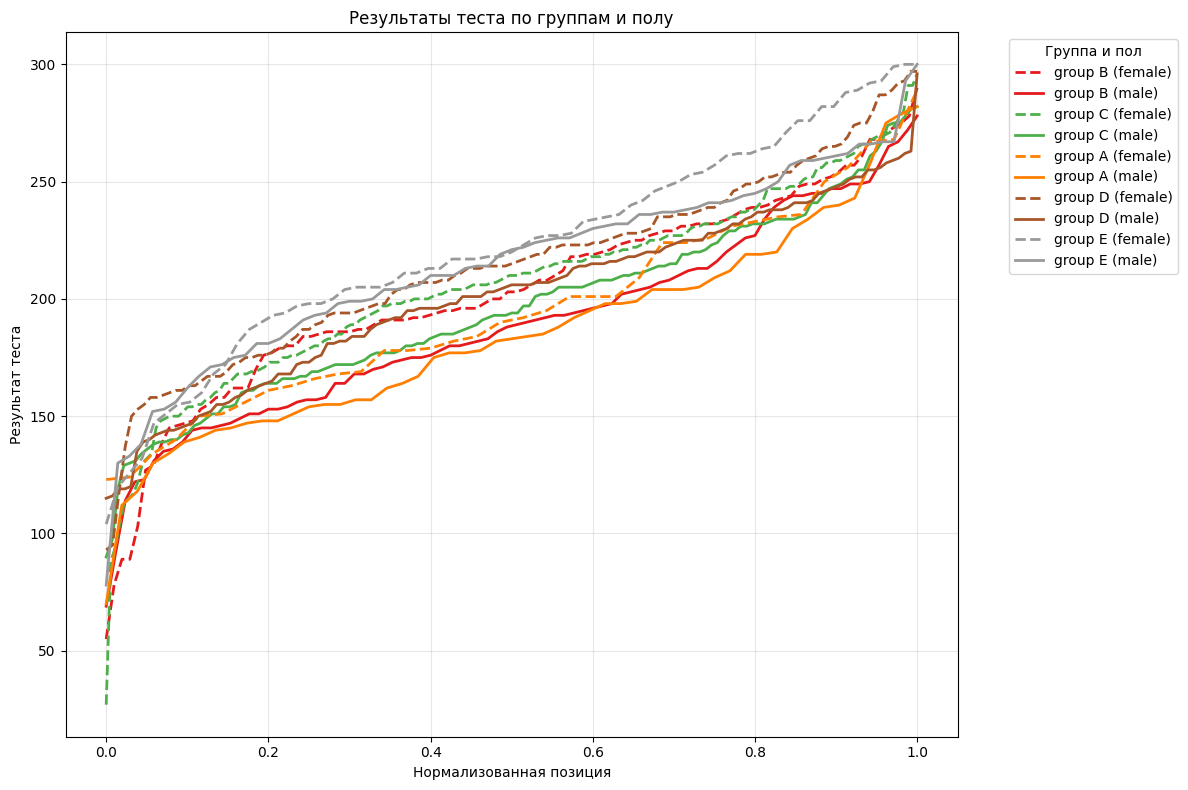

In [9]:
plt.figure(figsize=(12, 8))

# Определяем стили для разных полов
styles = {'M': '-', 'F': '--'}
colors = plt.cm.Set1(np.linspace(0, 1, len(df['race/ethnicity'].unique())))

for i, group_name in enumerate(df_plot['race/ethnicity'].unique()):
    for gender in df_plot['gender'].unique():
        style = 'M'
        subset = df_plot[(df_plot['race/ethnicity'] == group_name) & (df_plot['gender'] == gender)]
        if len(subset) > 0:
            sorted_values = np.sort(subset['sum score'])
            x_normalized = np.linspace(0, 1, len(sorted_values))
            
            label = f"{group_name} ({gender})"
            if gender == 'female':
                style = 'F'
            plt.plot(x_normalized, sorted_values, 
                    label=label, 
                    color=colors[i],
                    linestyle=styles[style],
                    marker='o' if len(sorted_values) < 10 else None,
                    linewidth=2)

plt.legend(title='Группа и пол', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Нормализованная позиция')
plt.ylabel('Результат теста')
plt.title('Результаты теста по группам и полу')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\mythys\AppData\Local\Temp\ipykernel_24632\3195582402.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normalized_data = df.groupby(['race/ethnicity', 'gender']).apply(create_normalized_positions).reset_index()


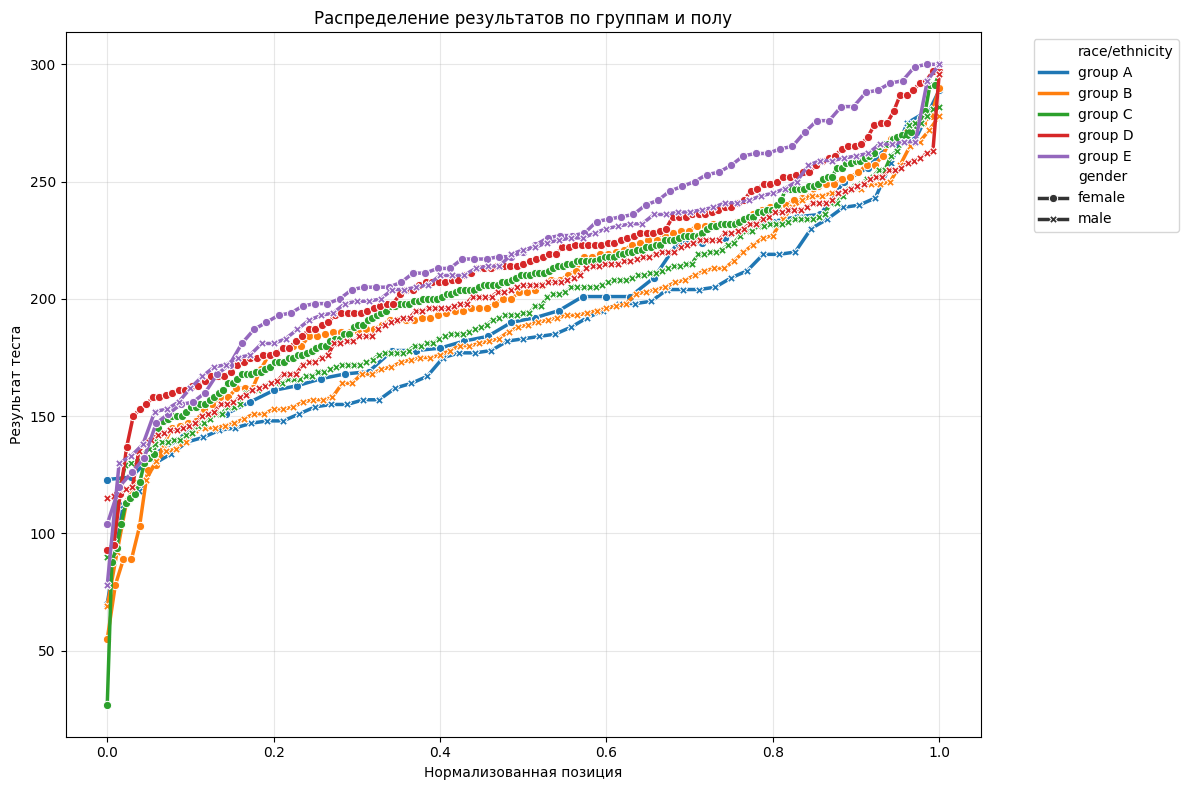

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def create_normalized_positions(df_subset):
    sorted_vals = np.sort(df_subset['sum score'])
    n = len(sorted_vals)
    return pd.DataFrame({
        'sum score': sorted_vals,
        'normalized_pos': np.linspace(0, 1, n)
    })

normalized_data = df.groupby(['race/ethnicity', 'gender']).apply(create_normalized_positions).reset_index()

plt.figure(figsize=(12, 8))
sns.lineplot(data=normalized_data, 
             x='normalized_pos', 
             y='sum score', 
             hue='race/ethnicity', 
             style='gender',
             markers=True, 
             dashes=False,
             linewidth=2.5)

plt.xlabel('Нормализованная позиция')
plt.ylabel('Результат теста')
plt.title('Распределение результатов по группам и полу')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Checking the Data

In [11]:
df.isna().sum()
# it means no imputing

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
sum score                      0
dtype: int64

In [12]:
df.info()
# all features are categoricals. it means no normalization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
 8   sum score                    1000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


## Tuning + Model making CatBoost

In [24]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import optuna

df_target = df['sum score']
df_scores = df[['math score', 'writing score', 'reading score']]
df_features = df.drop(columns=['sum score', 'math score', 'writing score', 'reading score'])
categorical_features = list(df_features.columns)
df_features = pd.get_dummies(df_features)
X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.2, random_state=42)

def objective_regularized(trial):    
    model_type = trial.suggest_categorical('model_type', ['ridge', 'lasso', 'elasticnet'])
    
    alpha = trial.suggest_float('alpha', 0.001, 10.0, log=True)
    
    if model_type == 'ridge':
        model = Ridge(alpha=alpha, random_state=42)
    elif model_type == 'lasso':
        model = Lasso(alpha=alpha, random_state=42)
    else:  # elasticnet
        l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
    
    # Fit and evaluate
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"R²: {r2:.4f}")
    return mse

study = optuna.create_study(direction='minimize')
study.optimize(objective_regularized, n_trials=100)

print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value:.4f}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")
best_params = study.best_params

[I 2025-11-17 22:29:12,566] A new study created in memory with name: no-name-aeb38c6a-076b-4fe0-8454-35354c76c6b2
[I 2025-11-17 22:29:12,574] Trial 0 finished with value: 1624.463172909447 and parameters: {'model_type': 'lasso', 'alpha': 0.09290786638251061}. Best is trial 0 with value: 1624.463172909447.
[I 2025-11-17 22:29:12,579] Trial 1 finished with value: 1635.3565141213764 and parameters: {'model_type': 'lasso', 'alpha': 0.20125022711496485}. Best is trial 0 with value: 1624.463172909447.
[I 2025-11-17 22:29:12,584] Trial 2 finished with value: 1616.5299315611 and parameters: {'model_type': 'ridge', 'alpha': 0.2506210336800049}. Best is trial 2 with value: 1616.5299315611.
c:\Users\mythys\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.0

R²: 0.1580
R²: 0.1524
R²: 0.1621
R²: 0.1621
R²: 0.1602
R²: 0.1622
R²: 0.1428
R²: 0.1259
R²: 0.1612
R²: 0.1609
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1606
R²: 0.1622
R²: 0.1622
R²: 0.0503
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1577


c:\Users\mythys\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.104e+03, tolerance: 1.436e+02
  model = cd_fast.enet_coordinate_descent(
[I 2025-11-17 22:29:12,779] Trial 29 finished with value: 1616.550666866886 and parameters: {'model_type': 'lasso', 'alpha': 0.0017809267799740011}. Best is trial 27 with value: 1616.4215354950172.
[I 2025-11-17 22:29:12,785] Trial 30 finished with value: 1616.4229507109856 and parameters: {'model_type': 'ridge', 'alpha': 0.004294328388392291}. Best is trial 27 with value: 1616.4215354950172.
[I 2025-11-17 22:29:12,792] Trial 31 finished with value: 1616.4215230719449 and parameters: {'model_type': 'ridge', 'alpha': 0.0010152662524345315}. Best is trial 31 with value: 1616.4215230719449.
[I 2025-11-17 22:29:12

R²: 0.1621
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1620
R²: 0.1622
R²: 0.1621
R²: 0.1622
R²: 0.1621
R²: 0.1622
R²: 0.1619
R²: 0.1620
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1620
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.0129
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622


[I 2025-11-17 22:29:12,987] Trial 55 finished with value: 1616.422177937986 and parameters: {'model_type': 'ridge', 'alpha': 0.0025193638725212342}. Best is trial 36 with value: 1616.4215224217485.
[I 2025-11-17 22:29:12,996] Trial 56 finished with value: 1616.4217002364896 and parameters: {'model_type': 'ridge', 'alpha': 0.0014221736832319605}. Best is trial 36 with value: 1616.4215224217485.
[I 2025-11-17 22:29:13,006] Trial 57 finished with value: 1616.421522706569 and parameters: {'model_type': 'ridge', 'alpha': 0.0010144270676368718}. Best is trial 36 with value: 1616.4215224217485.
[I 2025-11-17 22:29:13,014] Trial 58 finished with value: 1616.4231305847677 and parameters: {'model_type': 'ridge', 'alpha': 0.004707485341586961}. Best is trial 36 with value: 1616.4215224217485.
[I 2025-11-17 22:29:13,026] Trial 59 finished with value: 1616.6868408111454 and parameters: {'model_type': 'lasso', 'alpha': 0.003323373508046655}. Best is trial 36 with value: 1616.4215224217485.
[I 2025-1

R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1620
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1614
R²: 0.1622
R²: 0.1621
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1621
R²: 0.1622
R²: 0.1622
R²: 0.1621
R²: 0.1622
R²: 0.1620


[I 2025-11-17 22:29:13,194] Trial 80 finished with value: 1616.421866135256 and parameters: {'model_type': 'ridge', 'alpha': 0.001803209125001434}. Best is trial 71 with value: 1616.4215172763716.
[I 2025-11-17 22:29:13,200] Trial 81 finished with value: 1616.4216259319799 and parameters: {'model_type': 'ridge', 'alpha': 0.0012515124007933785}. Best is trial 71 with value: 1616.4215172763716.
[I 2025-11-17 22:29:13,210] Trial 82 finished with value: 1616.4215294370326 and parameters: {'model_type': 'ridge', 'alpha': 0.001029885381495698}. Best is trial 71 with value: 1616.4215172763716.
[I 2025-11-17 22:29:13,218] Trial 83 finished with value: 1616.421520775439 and parameters: {'model_type': 'ridge', 'alpha': 0.0010099917117072272}. Best is trial 71 with value: 1616.4215172763716.
[I 2025-11-17 22:29:13,225] Trial 84 finished with value: 1616.4220247782341 and parameters: {'model_type': 'ridge', 'alpha': 0.00216758221325341}. Best is trial 71 with value: 1616.4215172763716.
[I 2025-11-

R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1621
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1622
R²: 0.1619
Best trial:
  Value: 1616.4215
  Params: 
    model_type: ridge
    alpha: 0.0010017940652554073


In [ ]:
final_model = Ridge(**best_params)
final_model.fit(X_train,y_train)

y_pred = final_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
print(f"\nTest set RMSE: {test_rmse:.4f}")
print(f"Test set R²: {test_r2:.4f}")


TypeError: Ridge.__init__() got an unexpected keyword argument 'model_type'